In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**loading the dataset**

In [3]:
train = pd.read_csv("ir_train.csv")

In [4]:
train

,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,has_lhb_coaches,is_rake_shared,maintenance_score,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,0,1,5.5,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,1,6.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,1,0,4.1,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,1,0,5.5,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,0,1,8.0,0,1,0,64.3,Track Congestion,154,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,IR01569648,12784,Superfast Express,2020-04-02,2020,4,3,1,0,1,...,1,0,6.7,0,0,0,71.7,On Time,1,0
1499996,IR00761386,74780,DEMU/MEMU,2018-01-30,2018,1,1,18,0,0,...,1,1,6.0,0,0,1,42.5,Level Crossing Delay,139,1
1499997,IR01591784,74201,DEMU/MEMU,2020-05-28,2020,5,3,4,0,1,...,1,0,4.2,0,0,0,51.4,Level Crossing Delay,116,1
1499998,IR01421505,11433,Mail/Express,2021-04-08,2021,4,3,6,0,0,...,1,0,5.5,0,1,0,82.1,On Time,14,0


**Viewing the first 5 rows**


In [5]:
train.head()

,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,has_lhb_coaches,is_rake_shared,maintenance_score,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,0,1,5.5,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,1,6.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,1,0,4.1,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,1,0,5.5,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,0,1,8.0,0,1,0,64.3,Track Congestion,154,1


**Checking the dataset shape**

In [6]:
train.shape

(1500000, 44)

**Checking columns names**

In [7]:
train.columns

Index(['journey_id', 'train_number', 'train_type', 'departure_date', 'year',
       'month', 'day_of_week', 'departure_hour', 'is_weekend',
       'is_night_departure', 'is_peak_hour', 'is_festival_season', 'season',
       'zone', 'zone_abbr', 'source_station_category',
       'destination_station_category', 'distance_km', 'num_scheduled_stops',
       'scheduled_travel_hours', 'track_doubled', 'is_hdn_route',
       'traction_type', 'is_electrified', 'psr_count', 'is_circular_route',
       'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index',
       'zone_congestion_index', 'season_severity_score', 'loco_age_years',
       'coach_age_years', 'has_lhb_coaches', 'is_rake_shared',
       'maintenance_score', 'is_overloaded', 'late_incoming_rake',
       'is_special_train', 'route_historical_ontime_pct',
       'primary_delay_cause', 'delay_minutes', 'is_delayed'],
      dtype='str')

**Dataset information**

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 44 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   journey_id                    1500000 non-null  str    
 1   train_number                  1500000 non-null  int64  
 2   train_type                    1500000 non-null  str    
 3   departure_date                1500000 non-null  str    
 4   year                          1500000 non-null  int64  
 5   month                         1500000 non-null  int64  
 6   day_of_week                   1500000 non-null  int64  
 7   departure_hour                1500000 non-null  int64  
 8   is_weekend                    1500000 non-null  int64  
 9   is_night_departure            1500000 non-null  int64  
 10  is_peak_hour                  1500000 non-null  int64  
 11  is_festival_season            1500000 non-null  int64  
 12  season                        1500000 n

**Checking missing values**

In [9]:
train.isnull().sum()

journey_id                      0
train_number                    0
train_type                      0
departure_date                  0
year                            0
month                           0
day_of_week                     0
departure_hour                  0
is_weekend                      0
is_night_departure              0
is_peak_hour                    0
is_festival_season              0
season                          0
zone                            0
zone_abbr                       0
source_station_category         0
destination_station_category    0
distance_km                     0
num_scheduled_stops             0
scheduled_travel_hours          0
track_doubled                   0
is_hdn_route                    0
traction_type                   0
is_electrified                  0
psr_count                       0
is_circular_route               0
is_monsoon_season               0
is_fog_risk                     0
fog_risk_score                  0
zone_fog_index

**Statistical summary**

In [10]:
train.describe()

,train_number,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,coach_age_years,has_lhb_coaches,is_rake_shared,maintenance_score,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,delay_minutes,is_delayed
count,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,...,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1500000.0,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,2.366598e+04,2.021003e+03,6.517572e+00,3.000643e+00,1.311273e+01,2.863040e-01,1.006767e-01,4.681713e-01,1.801027e-01,6.099673e+02,...,2.312397e+01,5.996073e-01,4.497520e-01,6.481409e+00,0.0,3.491947e-01,9.996333e-02,6.301084e+01,9.772833e+01,7.188860e-01
std,2.103693e+04,2.000014e+00,3.448396e+00,2.001999e+00,5.832482e+00,4.520334e-01,3.009002e-01,4.989861e-01,3.842731e-01,3.712549e+02,...,1.169446e+01,4.899781e-01,4.974689e-01,1.757954e+00,0.0,4.767157e-01,2.999512e-01,1.248294e+01,6.617405e+01,4.495432e-01
min,1.110000e+04,2.018000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,...,2.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,0.0,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00
25%,1.190000e+04,2.019000e+03,4.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.420000e+02,...,1.380000e+01,0.000000e+00,0.000000e+00,5.300000e+00,0.0,0.000000e+00,0.000000e+00,5.430000e+01,1.300000e+01,0.000000e+00
50%,1.264700e+04,2.021000e+03,7.000000e+00,3.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.440000e+02,...,2.140000e+01,1.000000e+00,0.000000e+00,6.500000e+00,0.0,0.000000e+00,0.000000e+00,6.310000e+01,1.110000e+02,1.000000e+00
75%,2.222100e+04,2.023000e+03,1.000000e+01,5.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.920000e+02,...,3.130000e+01,1.000000e+00,1.000000e+00,7.700000e+00,0.0,1.000000e+00,0.000000e+00,7.180000e+01,1.400000e+02,1.000000e+00
max,8.299800e+04,2.024000e+03,1.200000e+01,6.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+03,...,4.500000e+01,1.000000e+00,1.000000e+00,1.000000e+01,0.0,1.000000e+00,1.000000e+00,9.500000e+01,5.790000e+02,1.000000e+00


**Target variable**

In [11]:
train["delay_minutes"].describe()

count    1.500000e+06
mean     9.772833e+01
std      6.617405e+01
min      0.000000e+00
25%      1.300000e+01
50%      1.110000e+02
75%      1.400000e+02
max      5.790000e+02
Name: delay_minutes, dtype: float64

**Exploratory Data Analysis(EDA)**

**Checking data types**

In [12]:
train.dtypes

journey_id                          str
train_number                      int64
train_type                          str
departure_date                      str
year                              int64
month                             int64
day_of_week                       int64
departure_hour                    int64
is_weekend                        int64
is_night_departure                int64
is_peak_hour                      int64
is_festival_season                int64
season                              str
zone                                str
zone_abbr                           str
source_station_category             str
destination_station_category        str
distance_km                       int64
num_scheduled_stops               int64
scheduled_travel_hours          float64
track_doubled                     int64
is_hdn_route                      int64
traction_type                       str
is_electrified                    int64
psr_count                         int64


**Checking duplicate rows**

In [13]:
train.duplicated().sum()

np.int64(0)

**Plotting the distribution of train delays**

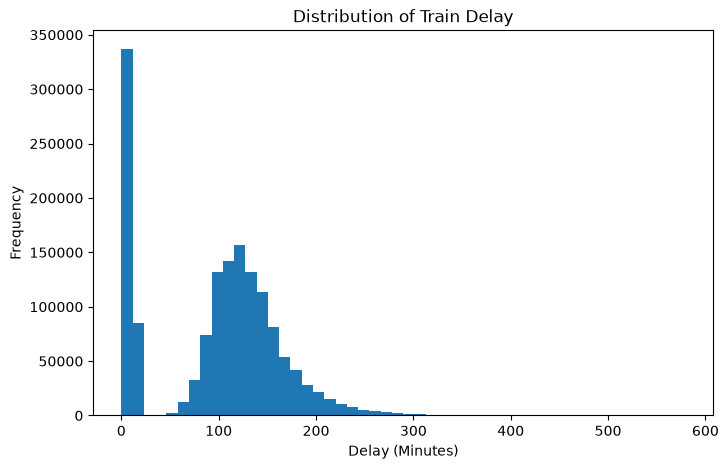

In [14]:
plt.figure(figsize=(8,5))
plt.hist(train["delay_minutes"], bins=50)
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Train Delay")
plt.show()

**Counting delayed VS on-time trains**

In [15]:
train["is_delayed"].value_counts()

is_delayed
1    1078329
0     421671
Name: count, dtype: int64

**Visualising**

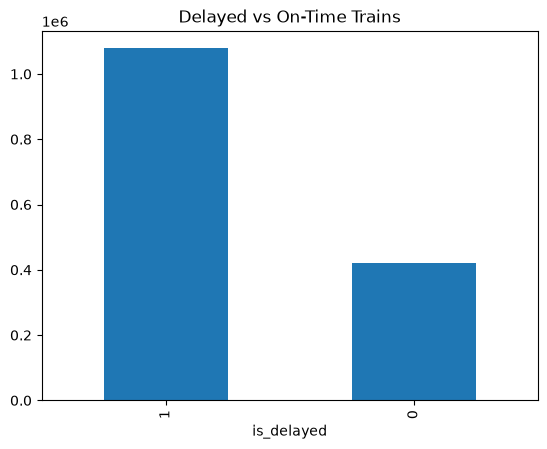

In [16]:
train["is_delayed"].value_counts().plot(kind="bar")
plt.title("Delayed vs On-Time Trains")
plt.show()

**Finding correlation b/w numericals features**

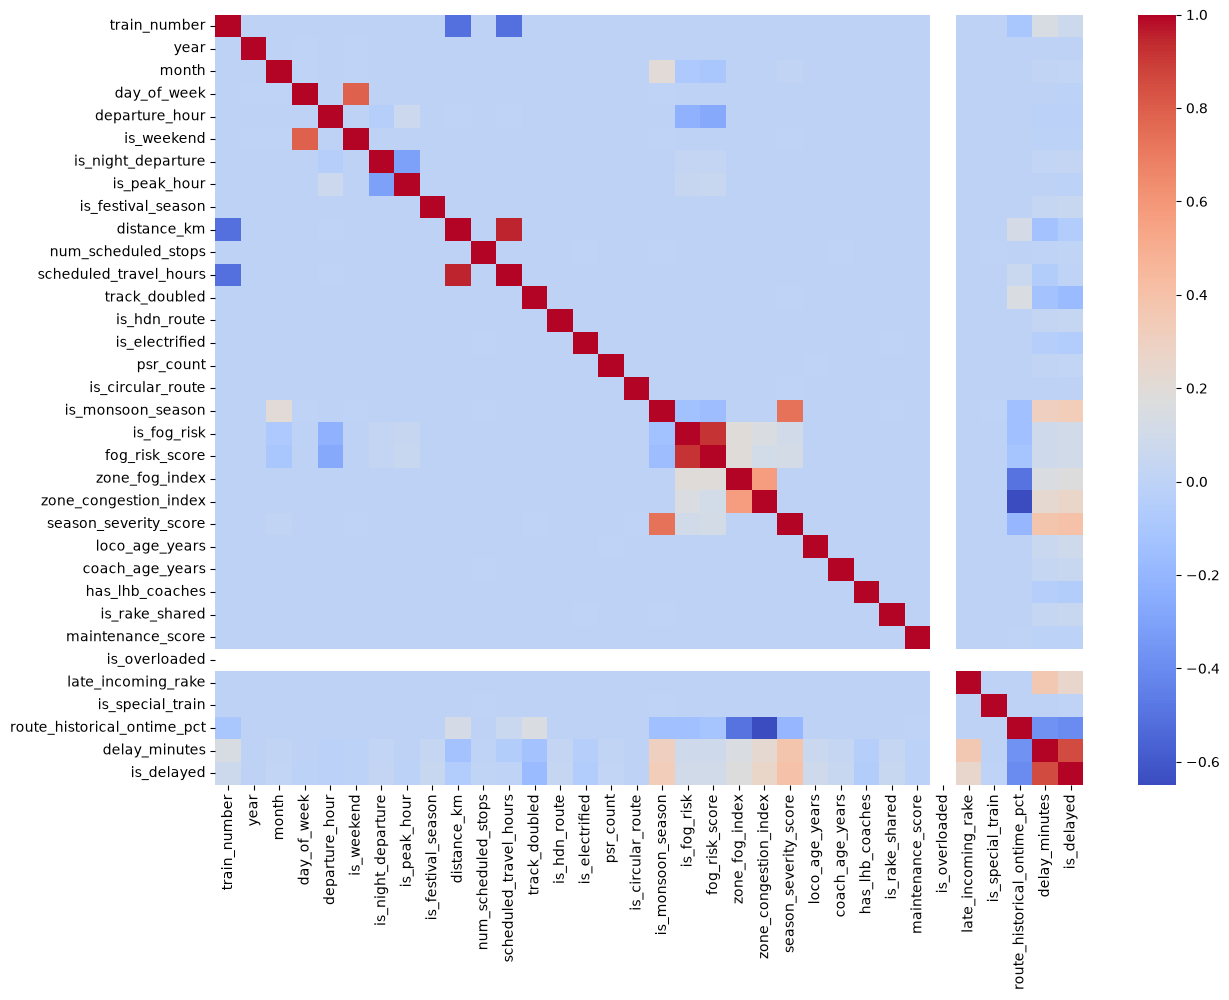

In [17]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

**Checking the most commmon train types**

In [18]:
train["train_type"].value_counts()

train_type
Mail/Express              421047
Superfast Express         179697
Intercity Express         150155
DEMU/MEMU                 149910
Passenger Train           119571
Jan Shatabdi Express       75120
Rajdhani Express           60178
Vande Bharat Express       59996
Shatabdi Express           59930
Sampark Kranti Express     59833
Duronto Express            45178
Humsafar Express           44886
Garib Rath Express         44761
Gatimaan Express           14899
Tejas Express              14839
Name: count, dtype: int64

**Average delay by train type**

In [19]:
train.groupby("train_type")["delay_minutes"].mean().sort_values(ascending=False)

train_type
Passenger Train           130.533198
DEMU/MEMU                 120.951371
Mail/Express              109.903835
Intercity Express         100.557404
Superfast Express          92.323250
Garib Rath Express         89.077054
Sampark Kranti Express     86.587502
Humsafar Express           85.357327
Jan Shatabdi Express       83.045461
Duronto Express            74.328501
Shatabdi Express           63.669281
Rajdhani Express           61.993935
Tejas Express              58.284723
Gatimaan Express           55.256997
Vande Bharat Express       50.976148
Name: delay_minutes, dtype: float64

**Average delay by season**

In [20]:
train.groupby("season")["delay_minutes"].mean()

season
Autumn           67.992339
Monsoon         126.675338
Post-Monsoon     78.518290
Pre-Monsoon      72.502750
Summer           65.107594
Winter/Fog      105.800649
Name: delay_minutes, dtype: float64

**Average delay by railway zone**

In [21]:
train.groupby("zone")["delay_minutes"].mean().sort_values(ascending=False)

zone
Eastern Railway (ER)                 120.518944
Northern Railway (NR)                118.031840
North Central Railway (NCR)          114.602289
East Central Railway (ECR)           114.029961
North Eastern Railway (NER)          107.411932
Central Railway (CR)                 106.502081
West Central Railway (WCR)           103.542838
Western Railway (WR)                 102.345303
North Western Railway (NWR)           98.058448
South Eastern Railway (SER)           91.672283
East Coast Railway (ECoR)             89.838356
South Central Railway (SCR)           87.416461
South East Central Railway (SECR)     87.382824
Southern Railway (SR)                 78.186407
Northeast Frontier Railway (NFR)      73.975676
South Western Railway (SWR)           70.295147
Name: delay_minutes, dtype: float64

**Checking the target variable**

In [22]:
train["delay_minutes"].describe()

count    1.500000e+06
mean     9.772833e+01
std      6.617405e+01
min      0.000000e+00
25%      1.300000e+01
50%      1.110000e+02
75%      1.400000e+02
max      5.790000e+02
Name: delay_minutes, dtype: float64

**DATA PREPROCESSING**

**One more time checking missing vakues**

In [23]:
train.isnull().sum().sort_values(ascending=False)

journey_id                      0
train_number                    0
train_type                      0
departure_date                  0
year                            0
month                           0
day_of_week                     0
departure_hour                  0
is_weekend                      0
is_night_departure              0
is_peak_hour                    0
is_festival_season              0
season                          0
zone                            0
zone_abbr                       0
source_station_category         0
destination_station_category    0
distance_km                     0
num_scheduled_stops             0
scheduled_travel_hours          0
track_doubled                   0
is_hdn_route                    0
traction_type                   0
is_electrified                  0
psr_count                       0
is_circular_route               0
is_monsoon_season               0
is_fog_risk                     0
fog_risk_score                  0
zone_fog_index

**Separate numerical and categorical columns***

In [24]:
num_cols = train.select_dtypes(include=['int64','float64']).columns

cat_cols = train.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['train_number', 'year', 'month', 'day_of_week', 'departure_hour',
       'is_weekend', 'is_night_departure', 'is_peak_hour',
       'is_festival_season', 'distance_km', 'num_scheduled_stops',
       'scheduled_travel_hours', 'track_doubled', 'is_hdn_route',
       'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season',
       'is_fog_risk', 'fog_risk_score', 'zone_fog_index',
       'zone_congestion_index', 'season_severity_score', 'loco_age_years',
       'coach_age_years', 'has_lhb_coaches', 'is_rake_shared',
       'maintenance_score', 'is_overloaded', 'late_incoming_rake',
       'is_special_train', 'route_historical_ontime_pct', 'delay_minutes',
       'is_delayed'],
      dtype='str')

Categorical Columns:
Index(['journey_id', 'train_type', 'departure_date', 'season', 'zone',
       'zone_abbr', 'source_station_category', 'destination_station_category',
       'traction_type', 'primary_delay_cause'],
      dtype='str')


C:\Users\arbaj\AppData\Local\Temp\ipykernel_18924\1444650705.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns


**converting data column**

*If departure_date is an object (string), convert it:*

In [25]:
train["departure_date"] = pd.to_datetime(train["departure_date"])

**creating new date features**

In [26]:
train["year"] = train["departure_date"].dt.year
train["month"] = train["departure_date"].dt.month
train["day"] = train["departure_date"].dt.day
train["weekday"] = train["departure_date"].dt.day_name()

**Encoding categorical variables**

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))

**Encoding the new weekday column**

In [28]:
train["weekday"] = LabelEncoder().fit_transform(train["weekday"])

**Verifying there is no object columns left**

In [29]:
train.dtypes

journey_id                        int64
train_number                      int64
train_type                        int64
departure_date                    int64
year                              int32
month                             int32
day_of_week                       int64
departure_hour                    int64
is_weekend                        int64
is_night_departure                int64
is_peak_hour                      int64
is_festival_season                int64
season                            int64
zone                              int64
zone_abbr                         int64
source_station_category           int64
destination_station_category      int64
distance_km                       int64
num_scheduled_stops               int64
scheduled_travel_hours          float64
track_doubled                     int64
is_hdn_route                      int64
traction_type                     int64
is_electrified                    int64
psr_count                         int64


**Selecting the target variable**

In [30]:
y = train["delay_minutes"]

**Selecting features**

**Note:** We are only dropping delay_minutes because
it is our prediction target, and departure_date
because we've already extracted useful information
(year, month, day, weekday) from it.

In [31]:
X = train.drop(columns=["delay_minutes",
                        "departure_date"])

**Train-test split**

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Checking the shapes**

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200000, 44)
(300000, 44)
(1200000,)
(300000,)


**Import LightGBM**


In [34]:
from lightgbm import LGBMRegressor

**Creating the model**

In [35]:
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

**Training the model**

In [36]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.124587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2177
[LightGBM] [Info] Number of data points in the train set: 1200000, number of used features: 43
[LightGBM] [Info] Start training from score 97.717842


,max_depth,8
,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**Predict**

In [37]:
y_pred = model.predict(X_test)

**Evaluating**

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 19.647830892892124
RMSE: 29.974657567806734
R² Score: 0.7950194697211341


**Plotting Actual VS Predicted**

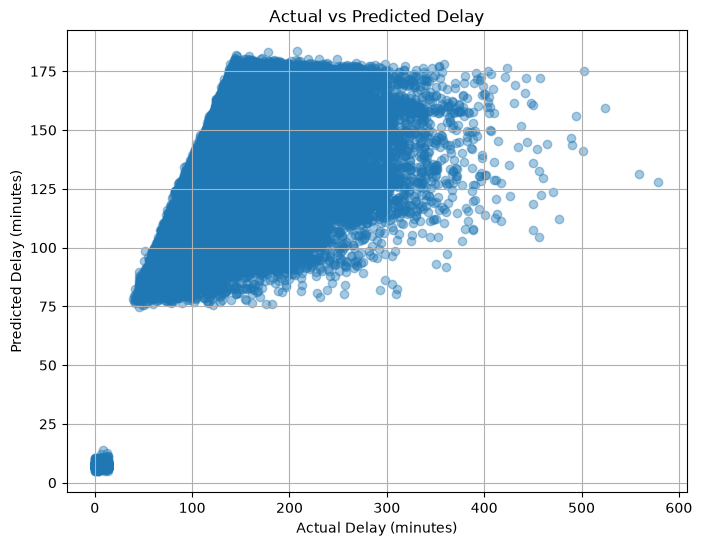

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Delay (minutes)")
plt.ylabel("Predicted Delay (minutes)")
plt.title("Actual vs Predicted Delay")
plt.grid(True)
plt.show()

**Feature Importance**
*This tells us which features influence train delays the most.*

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                         Feature  Importance
2                     train_type        1109
1                   train_number         943
30         season_severity_score         695
16                   distance_km         622
18        scheduled_travel_hours         580
39   route_historical_ontime_pct         518
29         zone_congestion_index         494
0                     journey_id         430
31                loco_age_years         406
32               coach_age_years         377
35             maintenance_score         354
42                           day         224
6                 departure_hour         220
40           primary_delay_cause         218
17           num_scheduled_stops         216
41                    is_delayed         207
37            late_incoming_rake         164
3                           year         137
23                     psr_count         133
15  destination_station_category          95


**Now plotting the top 20 features**

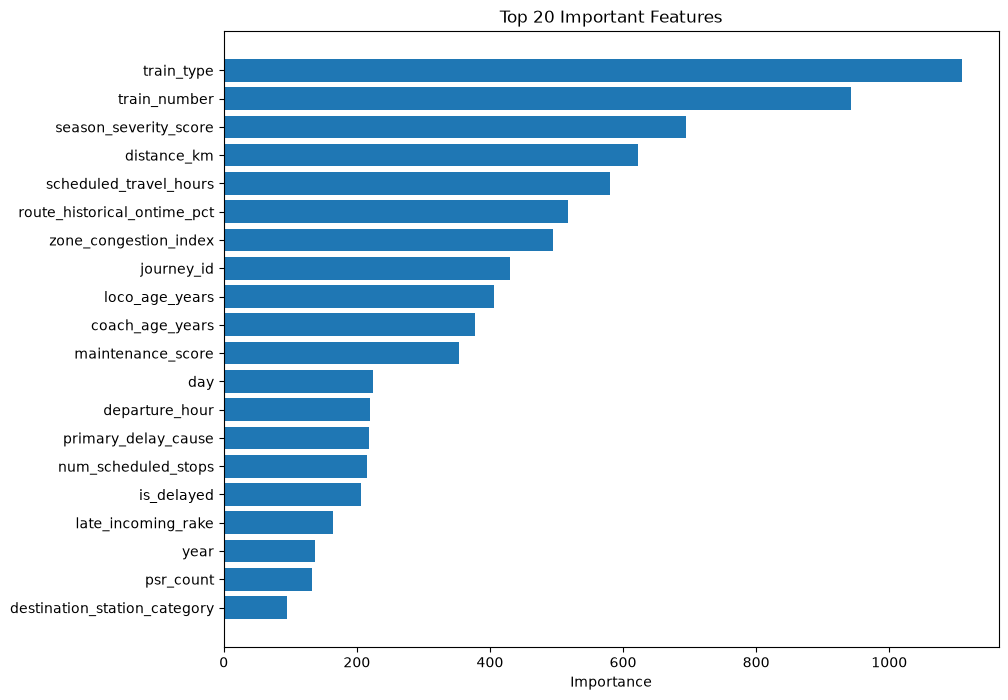

In [41]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

**Saving the trained model**

In [42]:
import joblib

joblib.dump(model, "railway_delay_model.pkl")

['railway_delay_model.pkl']

**Saving feature name**

In [43]:
feature_names = X_train.columns.tolist()

print(feature_names)

['journey_id', 'train_number', 'train_type', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'traction_type', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'primary_delay_cause', 'is_delayed', 'day', 'weekday']


In [44]:
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

**saving label encoder**

In [45]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

**loading saved files**

In [46]:
import joblib

# Load model
model = joblib.load("railway_delay_model.pkl")

# Load feature names
feature_names = joblib.load("feature_names.pkl")

# Load label encoders
label_encoders = joblib.load("label_encoders.pkl")

**Creating a prediction function**

In [47]:
print(feature_names)

['journey_id', 'train_number', 'train_type', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'traction_type', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'primary_delay_cause', 'is_delayed', 'day', 'weekday']


**create a prediction template**

In [48]:
input_data = pd.DataFrame(columns=feature_names)

input_data.loc[0] = 0

input_data

,journey_id,train_number,train_type,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,...,is_rake_shared,maintenance_score,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,is_delayed,day,weekday
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**filling user input**

In [49]:
input_data["train_number"] = 12951
input_data["year"] = 2026
input_data["month"] = 8
input_data["day"] = 15
input_data["weekday"] = 5

**make the prediction**

In [50]:
prediction = model.predict(input_data)

print(prediction)

[12.00882747]


**creating app.py**